<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Dm_ndm_cnn_28526.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
os.listdir('/content/drive/MyDrive/Keerthana menon postop DM and NDM fundus images original')

['Post op DM absent', 'Post op DM present']

In [4]:
import tensorflow as tf

dataset_path = '/content/drive/MyDrive/Keerthana menon postop DM and NDM fundus images original'

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names
print(class_names)

Found 72 files belonging to 2 classes.
Using 58 files for training.
Found 72 files belonging to 2 classes.
Using 14 files for validation.
['Post op DM absent', 'Post op DM present']


In [6]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)
model.save('fundus_image_cnn.keras')

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 21s 9s/step - accuracy: 0.3966 - loss: 0.7007 - val_accuracy: 0.7143 - val_loss: 0.6924
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.5172 - loss: 0.6927 - val_accuracy: 0.6429 - val_loss: 0.6924
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.4828 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 3s/step - accuracy: 0.4655 - loss: 0.6943 - val_accuracy: 0.5000 - val_loss: 0.6921
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 9s/step - accuracy: 0.5000 - loss: 0.6937 - val_accuracy: 0.5000 - val_loss: 0.6916
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.4138 - loss: 0.6974 - val_accuracy: 0.7143 - val_loss: 0.6909
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.4828 - loss: 0.6934 - val_accuracy: 0.6429 - val_loss: 0.6909
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.5690 - loss: 0.6877 - val_accuracy: 0.7143 - val_loss: 0.6901
Epoch 9/20

In [8]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step - accuracy: 0.7143 - loss: 0.6694
Validation Accuracy: 0.7142857313156128


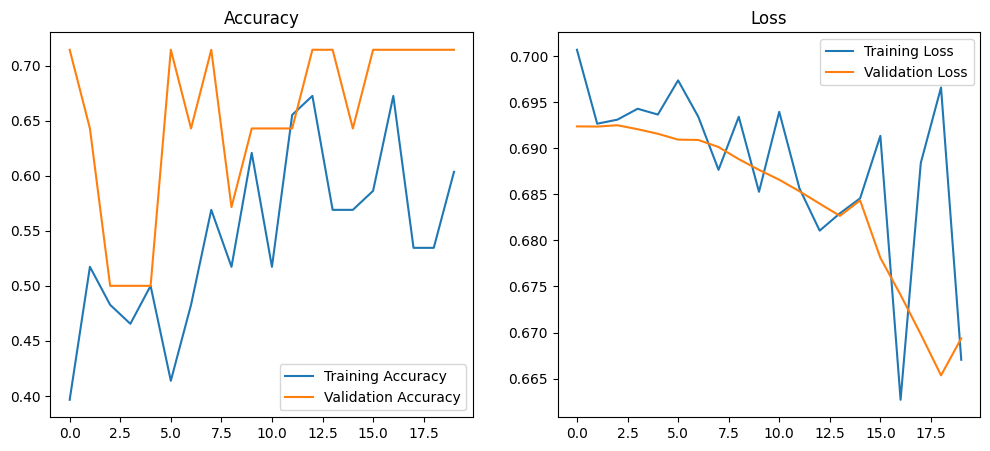

In [9]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

In [16]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions.flatten())

print(confusion_matrix(y_true, y_pred))

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step
[[5 2]
 [2 5]]
                    precision    recall  f1-score   support

 Post op DM absent       0.71      0.71      0.71         7
Post op DM present       0.71      0.71      0.71         7

          accuracy                           0.71        14
         macro avg       0.71      0.71      0.71        14
      weighted avg       0.71      0.71      0.71        14



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 807ms/step


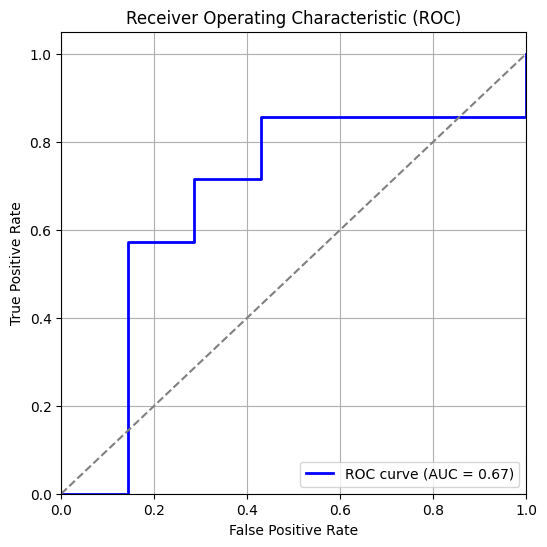

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# True labels and prediction probabilities
y_true = []
y_scores = []

for images, labels in val_ds:
    predictions = model.predict(images)

    y_true.extend(labels.numpy())
    y_scores.extend(predictions.flatten())

# Convert to numpy arrays
y_true = np.array(y_true)
y_scores = np.array(y_scores)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_scores)

# AUC score
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    color='blue',
    lw=2,
    label=f'ROC curve (AUC = {roc_auc:.2f})'
)

plt.plot([0,1], [0,1], color='gray', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
Prediction for /content/drive/MyDrive/Keerthana menon/DR/1.Mahadevamma shivanna.jpg:
  Class: Post op DM present
  Confidence: 0.5161


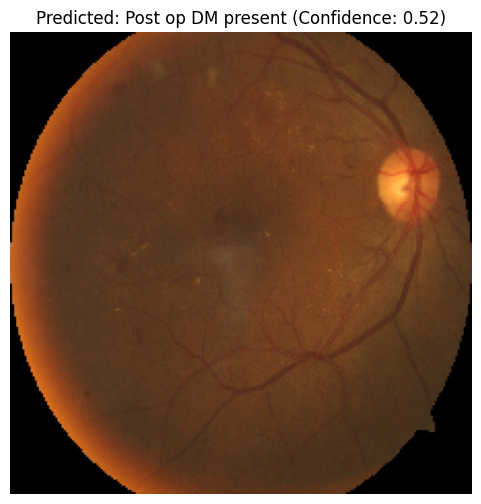

In [21]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import numpy as np

# Path to your test image
image_path = ('/content/drive/MyDrive/Keerthana menon/DR/1.Mahadevamma shivanna.jpg') # You might need to upload a test image or specify an existing path

# Load and preprocess the image
img = image.load_img(image_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Create a batch

# The model's first layer handles rescaling (1./255), so no manual rescaling needed here if it's already part of the model.
# If the model does NOT have a Rescaling layer, uncomment the line below:
# img_array = img_array / 255.0

# Make prediction
predictions = model.predict(img_array)

# Interpret the prediction
predicted_class_index = (predictions > 0.5).astype(int)[0][0]
predicted_class_name = class_names[predicted_class_index]
confidence = predictions[0][0]

print(f"Prediction for {image_path}:")
print(f"  Class: {predicted_class_name}")
print(f"  Confidence: {confidence:.4f}")

# Visualize the image and prediction
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"Predicted: {predicted_class_name} (Confidence: {confidence:.2f})")
plt.axis('off')
plt.show()

Using last convolutional layer: conv2d_5 for Grad-CAM.


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_12']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


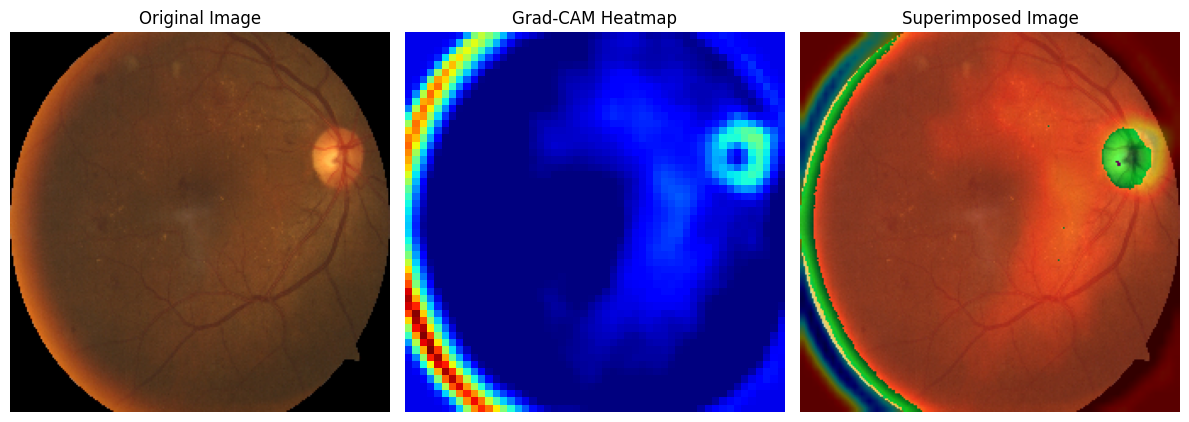

Predicted class: Post op DM present
Prediction confidence: 0.5161


In [27]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Reusing image_path from the previous cell for consistency
# Ensure 'image_path' is defined in a preceding cell or set it here.
# For example: image_path = '/content/drive/MyDrive/Keerthana menon/DR/1.Mahadevamma shivanna.jpg'

# Load and preprocess the image again for Grad-CAM
img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension

# Find the last convolutional layer in the model
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

if not last_conv_layer_name:
    raise ValueError("No Conv2D layer found in the model for Grad-CAM.")

print(f"Using last convolutional layer: {last_conv_layer_name} for Grad-CAM.")

# 1. Create a model that maps the input image to the activations of the last conv layer
grad_model_intermediate = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=model.get_layer(last_conv_layer_name).output
)

# 2. Create a model that maps the activations of the last conv layer to the final class prediction
last_conv_layer = model.get_layer(last_conv_layer_name)
classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
x = classifier_input
# Iterate through layers AFTER the last convolutional layer
for layer in model.layers[model.layers.index(last_conv_layer) + 1:]:
    x = layer(x)
classifier_model = tf.keras.models.Model(classifier_input, x)

# Compute gradients
with tf.GradientTape() as tape:
    # Compute activations of the last conv layer for the image
    last_conv_layer_output = grad_model_intermediate(img_array)

    # Explicitly watch this intermediate tensor for gradient calculation
    tape.watch(last_conv_layer_output)

    # Compute the raw predictions from these activations using the classifier part
    raw_predictions = classifier_model(last_conv_layer_output)

    # Determine the target score for gradient calculation
    # For binary classification with sigmoid output (single value for probability of class 1)
    prediction_value = raw_predictions[0, 0] # Get the scalar probability of class 1

    # Use tf.cond for differentiable conditional selection of the target score
    target_score = tf.cond(
        prediction_value > 0.5,
        lambda: prediction_value, # Maximize probability of class 1
        lambda: 1.0 - prediction_value # Maximize probability of class 0
    )

# Compute the gradient of the target score with respect to the activations of the last conv layer
grads = tape.gradient(target_score, last_conv_layer_output)

# Now, for printing the actual predicted class and confidence
predictions = raw_predictions
predicted_class_idx = (predictions > 0.5).numpy().astype(int)[0][0]
confidence = predictions.numpy()[0][0]

# Pool the gradients over all the spatial dimensions to get importance weights for each filter
if grads is None:
    print("Warning: Gradients are still None. This indicates a deeper issue with differentiability.")
    print("Defaulting heatmap to zeros.")
    heatmap = tf.zeros_like(last_conv_layer_output[0, :, :, 0]) # Create a zero heatmap
else:
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiply each channel in the feature map by its corresponding importance weight
    last_conv_layer_output = last_conv_layer_output[0] # Remove batch dimension
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap) # Remove the last dimension of 1

    # Normalize the heatmap to be between 0 and 1
    # Handle cases where max_heatmap_value is 0 to avoid division by zero
    max_heatmap_value = tf.reduce_max(heatmap)
    if max_heatmap_value == 0:
        heatmap = tf.zeros_like(heatmap)
    else:
        heatmap = tf.maximum(heatmap, 0) / max_heatmap_value

# Convert original image to numpy array for visualization (scaled 0-1)
original_img_np = tf.keras.preprocessing.image.img_to_array(img) / 255.0

# Resize heatmap to the original image size and apply a colormap
heatmap_display = cv2.resize(heatmap.numpy(), (original_img_np.shape[1], original_img_np.shape[0]))
heatmap_display = np.uint8(255 * heatmap_display) # Convert to 0-255 scale
heatmap_display = cv2.applyColorMap(heatmap_display, cv2.COLORMAP_JET) # Apply jet colormap

# Superimpose the heatmap on the original image
# Convert original_img_np back to 0-255 scale for superimposition with heatmap_display
superimposed_img = heatmap_display * 0.4 + original_img_np * 255 # 0.4 is transparency factor
superimposed_img = np.uint8(superimposed_img)

# Display the results
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(img) # Display original PIL image
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap.numpy(), cmap='jet')
plt.title('Grad-CAM Heatmap')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title('Superimposed Image')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Predicted class: {class_names[predicted_class_idx]}")
print(f"Prediction confidence: {confidence:.4f}")

Using last convolutional layer: conv2d_5 for Grad-CAM.


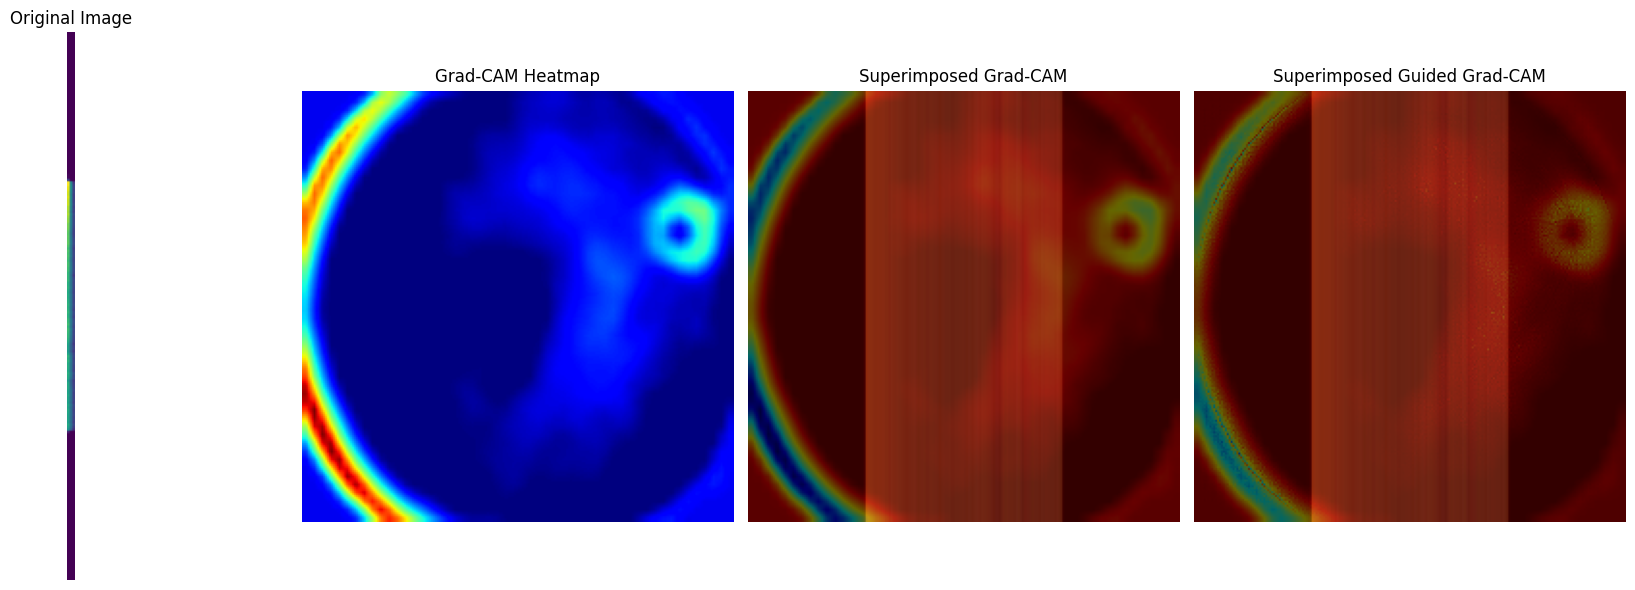

Predicted class: Post op DM present
Prediction confidence: 0.5161


In [31]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# --- Custom Guided ReLU Layer ---
# This layer implements the custom gradient for Guided Backpropagation.
# It ensures that only positive gradients are propagated through positive activations.
class GuidedReLU(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(GuidedReLU, self).__init__(**kwargs)

    @tf.custom_gradient
    def call_guided_relu(self, x):
        def grad(dy):
            # The core of Guided Backpropagation: only propagate positive gradients
            # through positive activations, and positive gradients through positive inputs.
            return tf.cast(dy > 0, dtype=x.dtype) * tf.cast(x > 0, dtype=x.dtype) * dy
        return tf.nn.relu(x), grad

    def call(self, inputs):
        return self.call_guided_relu(inputs)

# --- Function to build a Guided Backprop Model using Functional API ---
# This function clones the original model and replaces all ReLU activations
# with our custom GuidedReLU layer using the Keras Functional API, allowing
# for precise weight transfer.
def build_guided_backprop_model_functional(original_model):
    # Get the input tensor from the original model
    input_tensor = tf.keras.Input(shape=original_model.input_shape[1:])
    x = input_tensor

    # Keep track of the original model's trainable layers and their weights
    original_trainable_layers_info = []
    for layer in original_model.layers:
        if layer.weights: # Only layers with weights (Conv2D, Dense)
            original_trainable_layers_info.append({'name': layer.name, 'weights': layer.get_weights()})

    current_trainable_layer_idx = 0

    # Iterate through the original model's layers to build the new functional model
    for original_l in original_model.layers:
        layer_config = original_l.get_config()

        # Handle layers that have activations or weights
        if isinstance(original_l, (tf.keras.layers.Conv2D, tf.keras.layers.Dense)):
            if hasattr(original_l, 'activation') and original_l.activation == tf.keras.activations.relu:
                # Recreate the layer without activation
                layer_config['activation'] = None
                new_l_no_activation = type(original_l).from_config(layer_config)
                x = new_l_no_activation(x)
                x = GuidedReLU()(x) # Insert GuidedReLU after it

                # Transfer weights
                if original_l.weights: # This should always be true for Conv2D/Dense
                    new_l_no_activation.set_weights(original_trainable_layers_info[current_trainable_layer_idx]['weights'])
                    current_trainable_layer_idx += 1
            else:
                # For layers with non-ReLU activation or no activation (like the final sigmoid Dense)
                new_l = type(original_l).from_config(layer_config)
                x = new_l(x)
                # Transfer weights
                if original_l.weights:
                    new_l.set_weights(original_trainable_layers_info[current_trainable_layer_idx]['weights'])
                    current_trainable_layer_idx += 1
        elif isinstance(original_l, tf.keras.layers.Activation) and original_l.activation == tf.keras.activations.relu:
            # Replace standalone ReLU activation layer with GuidedReLU
            x = GuidedReLU()(x)
        else:
            # For stateless layers (Rescaling, MaxPooling, Dropout, GlobalAveragePooling)
            # Just create a new instance and pass the tensor through it.
            # These layers don't have weights to transfer.
            new_l = type(original_l).from_config(layer_config)
            x = new_l(x)

    # Create the new functional model
    guided_backprop_model = tf.keras.models.Model(inputs=input_tensor, outputs=x)
    return guided_backprop_model

# --- Grad-CAM and Guided Grad-CAM Computation ---

# Load and preprocess the image (image_path, model, class_names are assumed to be available)
img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
img_array_preprocessed = tf.keras.preprocessing.image.img_to_array(img)
# The model's first layer is Rescaling(1./255), so no manual rescaling needed here before passing to model
img_array_for_model = np.expand_dims(img_array_preprocessed, axis=0) # Add batch dimension

# Convert to tf.Tensor for gradient tape operations
input_img_tensor = tf.convert_to_tensor(img_array_for_model, dtype=tf.float32)

# Find the last convolutional layer in the original model
last_conv_layer_name = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break
if not last_conv_layer_name:
    raise ValueError("No Conv2D layer found in the model for Grad-CAM.")
print(f"Using last convolutional layer: {last_conv_layer_name} for Grad-CAM.")

# 1. Grad-CAM Intermediate and Classifier Models (re-used from previous approach)
# Model that maps the input image to the activations of the last conv layer
grad_model_intermediate = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=model.get_layer(last_conv_layer_name).output
)
# Model that maps the activations of the last conv layer to the final class prediction
last_conv_layer = model.get_layer(last_conv_layer_name)
classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
x_classifier = classifier_input
# Iterate through layers AFTER the last convolutional layer to build the classifier part
for layer in model.layers[model.layers.index(last_conv_layer) + 1:]:
    x_classifier = layer(x_classifier)
classifier_model = tf.keras.models.Model(classifier_input, x_classifier)

# --- Grad-CAM Heatmap Calculation ---
with tf.GradientTape() as tape:
    # Get activations of the last convolutional layer
    last_conv_layer_output = grad_model_intermediate(input_img_tensor)
    tape.watch(last_conv_layer_output) # Watch for gradients

    # Get raw predictions from these activations
    raw_predictions = classifier_model(last_conv_layer_output)

    # Determine the target score for gradient calculation (for binary sigmoid output)
    prediction_value = raw_predictions[0, 0] # Scalar probability of class 1
    target_score = tf.cond(
        prediction_value > 0.5,
        lambda: prediction_value, # Maximize probability of class 1
        lambda: 1.0 - prediction_value # Maximize probability of class 0
    )

grads = tape.gradient(target_score, last_conv_layer_output)

# Get prediction details for display (using raw_predictions)
predictions_np = raw_predictions.numpy()
predicted_class_idx = (predictions_np > 0.5).astype(int)[0][0]
confidence = predictions_np[0][0]

# Process gradients to create the Grad-CAM heatmap
if grads is None:
    print("Warning: Gradients for Grad-CAM are None. Defaulting heatmap to zeros.")
    heatmap_raw = tf.zeros_like(last_conv_layer_output[0, :, :, 0])
else:
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2)) # Global average pool of gradients
    last_conv_layer_output = last_conv_layer_output[0] # Remove batch dimension
    heatmap_raw = last_conv_layer_output @ pooled_grads[..., tf.newaxis] # Weighted sum
    heatmap_raw = tf.squeeze(heatmap_raw) # Remove extra dimension

    # Normalize heatmap (ReLU and scale 0-1)
    max_heatmap_value = tf.reduce_max(heatmap_raw)
    if max_heatmap_value == 0:
        heatmap = tf.zeros_like(heatmap_raw)
    else:
        heatmap = tf.maximum(heatmap_raw, 0) / max_heatmap_value

# Upsample the Grad-CAM heatmap to the original image size
heatmap_upsampled = cv2.resize(heatmap.numpy(), (224, 224))


# --- Guided Backpropagation Map Calculation ---
# Build the specialized model for Guided Backpropagation using the functional API
guided_backprop_model = build_guided_backprop_model_functional(model)

with tf.GradientTape() as tape:
    # We need to watch the input_img_tensor directly for gradients w.r.t input image
    tape.watch(input_img_tensor)

    # Forward pass through the guided model to get predictions
    guided_predictions_output = guided_backprop_model(input_img_tensor)

    # Get the target score for gradient calculation (same logic as Grad-CAM)
    guided_prediction_value = guided_predictions_output[0, 0]
    guided_target_score = tf.cond(
        guided_prediction_value > 0.5,
        lambda: guided_prediction_value,
        lambda: 1.0 - guided_prediction_value
    )

# Compute gradients of the target score w.r.t. the input image (Guided Backprop map)
guided_grads_raw = tape.gradient(guided_target_score, input_img_tensor)

# Normalize Guided Backprop map for visualization (scale 0-1)
# The output is (1, H, W, C), take [0] to remove batch dim.
guided_backprop_map = guided_grads_raw[0].numpy()
guided_backprop_map = (guided_backprop_map - guided_backprop_map.min()) / (guided_backprop_map.max() - guided_backprop_map.min() + 1e-8)


# --- Guided Grad-CAM Combination ---
# Element-wise product of (upsampled) Grad-CAM heatmap and Guided Backprop map.
# The heatmap_upsampled is (224, 224), guided_backprop_map is (224, 224, 3).
# Expand heatmap_upsampled to (224, 224, 1) for element-wise multiplication.
guided_gradcam_map = heatmap_upsampled[..., np.newaxis] * guided_backprop_map

# Normalize the final Guided Grad-CAM map
guided_gradcam_map = (guided_gradcam_map - guided_gradcam_map.min()) / (guided_gradcam_map.max() - guided_gradcam_map.min() + 1e-8)

# Original image for superposition (converted to 0-255 numpy array)
original_img_for_display = np.uint8(img_array_preprocessed[0]) # Assuming img_array_preprocessed is 0-255 already from PIL


# --- Visualization ---
plt.figure(figsize=(18, 6)) # Increased figure width for 4 plots

plt.subplot(1, 4, 1)
plt.imshow(original_img_for_display)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 4, 2)
# Grad-CAM heatmap (single channel, needs colormap)
plt.imshow(heatmap_upsampled, cmap='jet')
plt.title('Grad-CAM Heatmap')
plt.axis('off')

plt.subplot(1, 4, 3)
# Superimposed Grad-CAM (re-create for consistency)
heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_upsampled), cv2.COLORMAP_JET)
superimposed_gradcam_img = heatmap_colored * 0.4 + original_img_for_display * 0.6
superimposed_gradcam_img = np.uint8(superimposed_gradcam_img)
plt.imshow(superimposed_gradcam_img)
plt.title('Superimposed Grad-CAM')
plt.axis('off')

plt.subplot(1, 4, 4)
# Superimposed Guided Grad-CAM
# For visualization, convert the 3-channel guided_gradcam_map (normalized) to a single-channel intensity,
# then apply a colormap, and superimpose on the original image.
guided_gradcam_intensity = np.mean(guided_gradcam_map, axis=-1) # Take mean across channels for intensity
guided_gradcam_colored = cv2.applyColorMap(np.uint8(255 * guided_gradcam_intensity), cv2.COLORMAP_JET)

superimposed_guided_gradcam_img_final = guided_gradcam_colored * 0.4 + original_img_for_display * 0.6
superimposed_guided_gradcam_img_final = np.uint8(superimposed_guided_gradcam_img_final)

plt.imshow(superimposed_guided_gradcam_img_final)
plt.title('Superimposed Guided Grad-CAM')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Predicted class: {class_names[predicted_class_idx]}")
print(f"Prediction confidence: {confidence:.4f}")